# Exploratory Data Analysis (EDA)

In [1]:
# Import library yang dibutuhkan
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")

## 1. Setup Direktori dan Path
Mendefinisikan path menuju folder `output` (wajah yang sudah di-crop) dan `train` (foto asli).

In [6]:
# Karena notebook berada di folder 'Notebook', kita naik satu tingkat ke 'FaceBoundingBox'
BASE_DIR = '../FaceBoundingBox'
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
TRAIN_DIR = os.path.join(BASE_DIR, 'train')

# Mendata kelas yang ada di folder output
classes = [d for d in os.listdir(OUTPUT_DIR) if os.path.isdir(os.path.join(OUTPUT_DIR, d))]
print(f"Daftar Kelas: {classes}")

Daftar Kelas: ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']


## 2. Distribusi Kelas (Data Cropped)
Melihat jumlah gambar untuk masing-masing kategori (seperti *realperson*, *fake_mask*, dll.) di dalam folder `output` untuk memastikan apakah data kita seimbang (*balanced*) atau tidak.

C:\Users\hafiz\AppData\Local\Temp\ipykernel_24532\4206374193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Jumlah Gambar', y='Kelas', data=df_counts, palette='viridis')


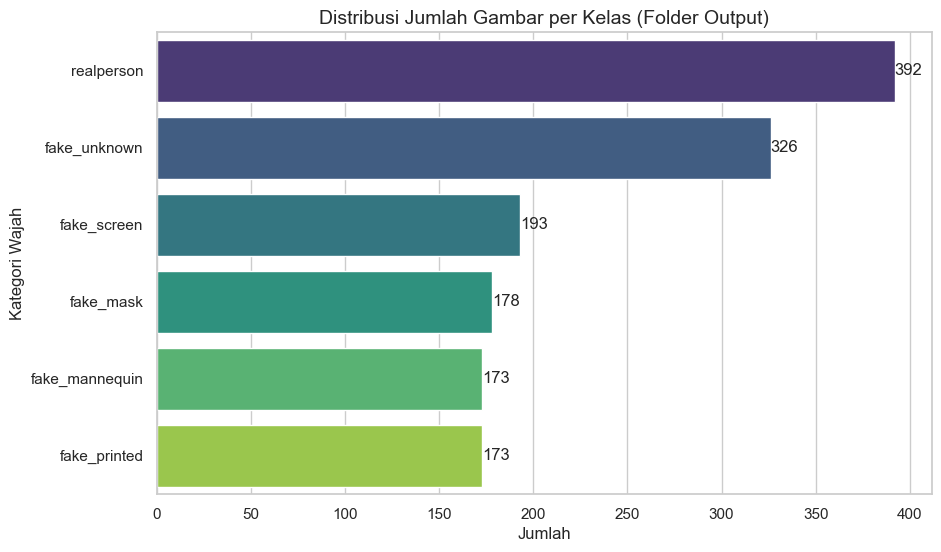

In [7]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(OUTPUT_DIR, cls)
    # Menghitung jumlah file dengan ekstensi gambar umum
    num_images = len(glob.glob(os.path.join(class_path, '*.*')))
    class_counts[cls] = num_images

# Konversi ke DataFrame untuk kemudahan plotting
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Kelas', 'Jumlah Gambar'])
df_counts = df_counts.sort_values(by='Jumlah Gambar', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Jumlah Gambar', y='Kelas', data=df_counts, palette='viridis')
plt.title('Distribusi Jumlah Gambar per Kelas (Folder Output)', fontsize=14)
plt.xlabel('Jumlah')
plt.ylabel('Kategori Wajah')

# Menambahkan label angka di bar
for i in ax.containers:
    ax.bar_label(i,)

plt.show()

## 3. Visualisasi Sampel Wajah (Cropped)
Menampilkan satu sampel gambar dari masing-masing kelas di folder `output` agar kita tahu seperti apa hasil *cropping* wajahnya.

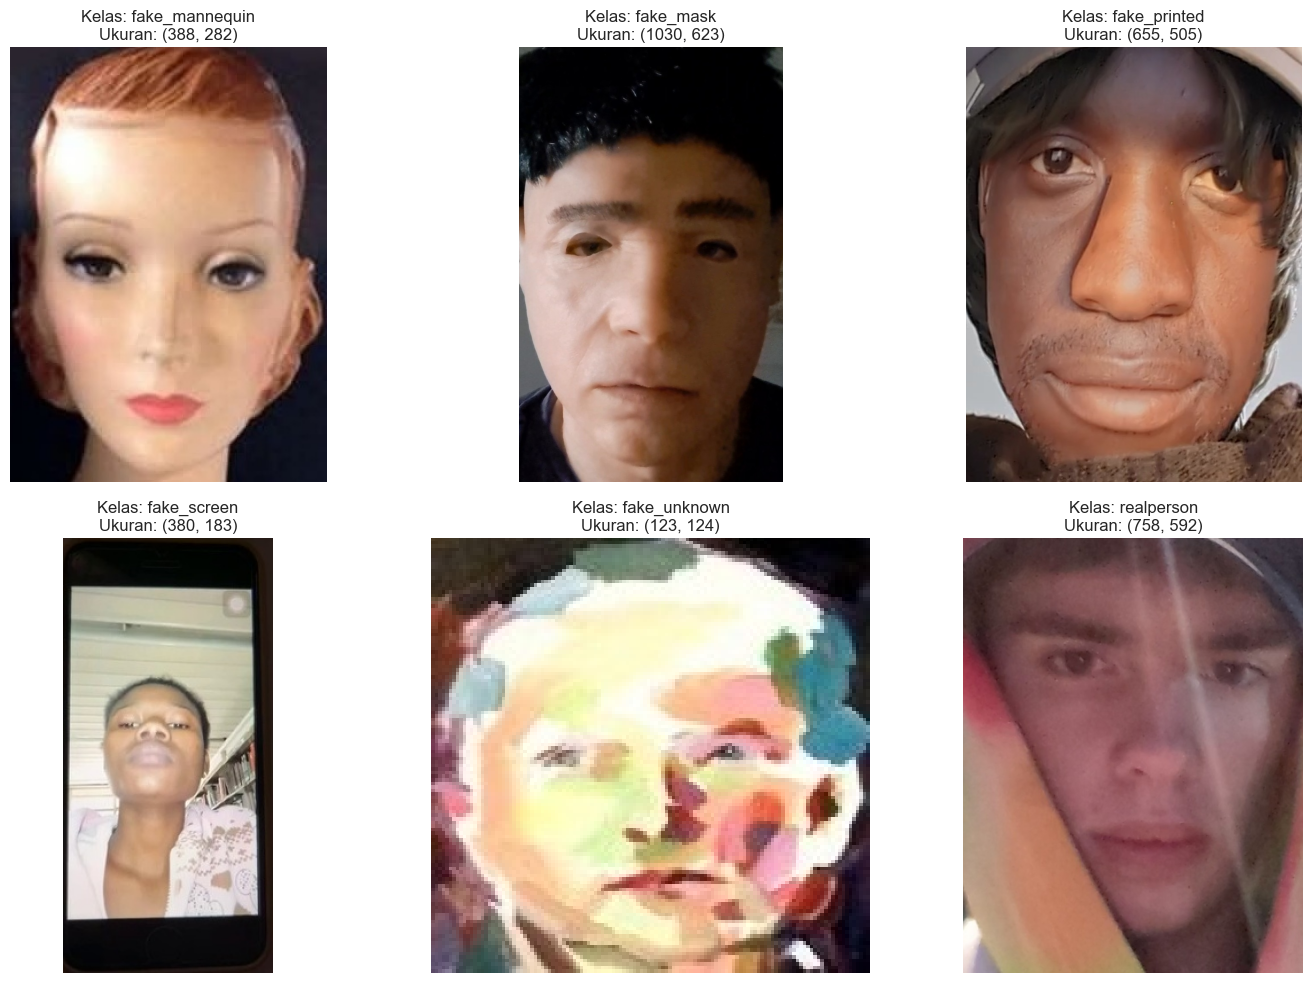

In [8]:
plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes):
    class_path = os.path.join(OUTPUT_DIR, cls)
    # Ambil satu gambar pertama dari folder kelas tersebut
    image_files = glob.glob(os.path.join(class_path, '*.*'))
    
    if image_files:
        img_path = image_files[0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV membaca BGR, kita ubah ke RGB
        
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Kelas: {cls}\nUkuran: {img.shape[:2]}")
        plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Visualisasi Sampel Foto Asli (Train)
Melihat sampel foto asli dari folder `train` yang belum melewati proses *cropping* untuk memahami konteks gambar utuhnya.

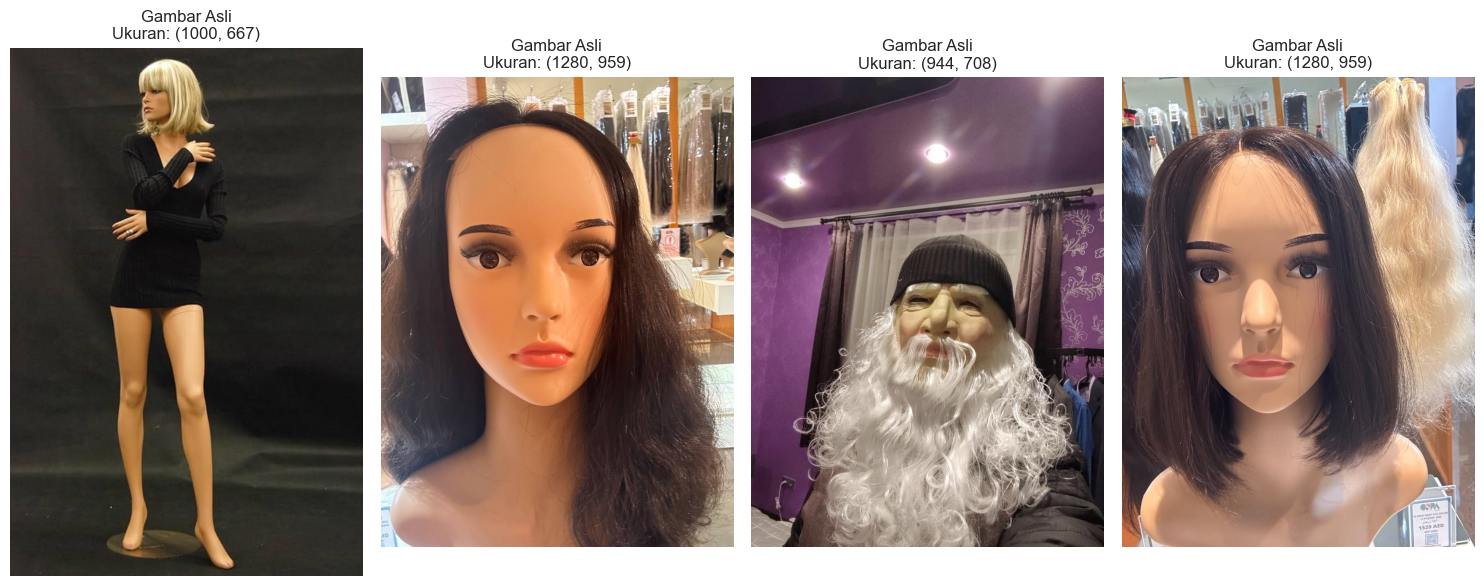

In [9]:
# Ambil beberapa gambar dari folder train
train_images = glob.glob(os.path.join(TRAIN_DIR, '*.*'))[:4] # Ambil 4 sampel

if train_images:
    plt.figure(figsize=(15, 8))
    for i, img_path in enumerate(train_images):
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(1, 4, i + 1)
            plt.imshow(img)
            plt.title(f"Gambar Asli\nUkuran: {img.shape[:2]}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ditemukan file gambar di folder train.")

## 5. Analisis Dimensi Gambar (Folder Output)
Pengecekan resolusi ini sangat membantu untuk menentukan ukuran *input shape* (misalnya disamakan menjadi 224x224 atau 299x299) jika Anda merencanakan ekstraksi fitur dan pemodelan menggunakan arsitektur CNN atau pre-trained model seperti InceptionV3.

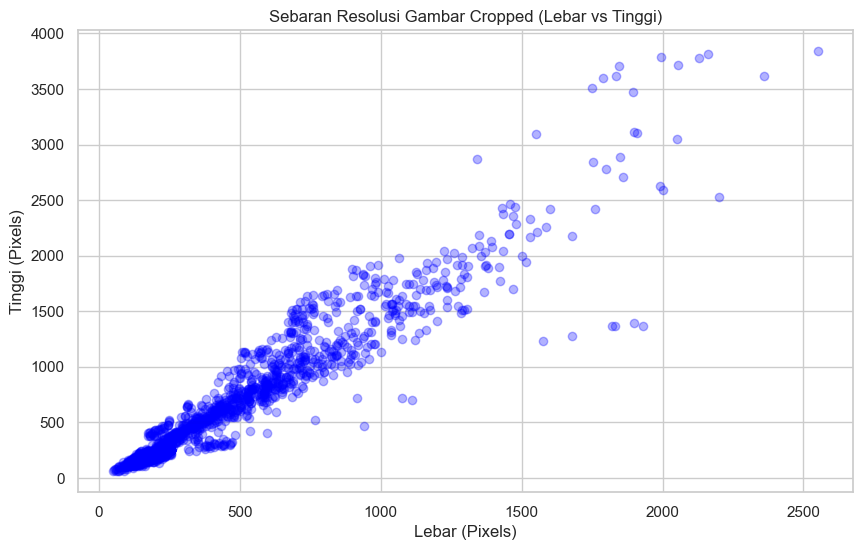

Rata-rata Lebar: 496.34 pixels
Rata-rata Tinggi: 709.03 pixels


In [16]:
widths = []
heights = []

# Mengambil sampel maksimal 500 gambar per kelas agar proses tidak terlalu lama
for cls in classes:
    class_path = os.path.join(OUTPUT_DIR, cls)
    image_files = glob.glob(os.path.join(class_path, '*.*'))[:500]
    
    for img_path in image_files:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except:
            pass

plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.3, color='blue')
plt.title('Sebaran Resolusi Gambar Cropped (Lebar vs Tinggi)')
plt.xlabel('Lebar (Pixels)')
plt.ylabel('Tinggi (Pixels)')
plt.grid(True)
plt.show()

print(f"Rata-rata Lebar: {np.mean(widths):.2f} pixels")
print(f"Rata-rata Tinggi: {np.mean(heights):.2f} pixels")

## 6. Analisis Dimensi Gambar (Folder Train)
Setelah mengetahui sebaran resolusi pada wajah yang sudah di-crop, kita juga perlu melihat sebaran resolusi pada foto aslinya. Hal ini berguna untuk mengetahui seberapa besar resolusi gambar sumber sebelum diproses oleh *face detector*.

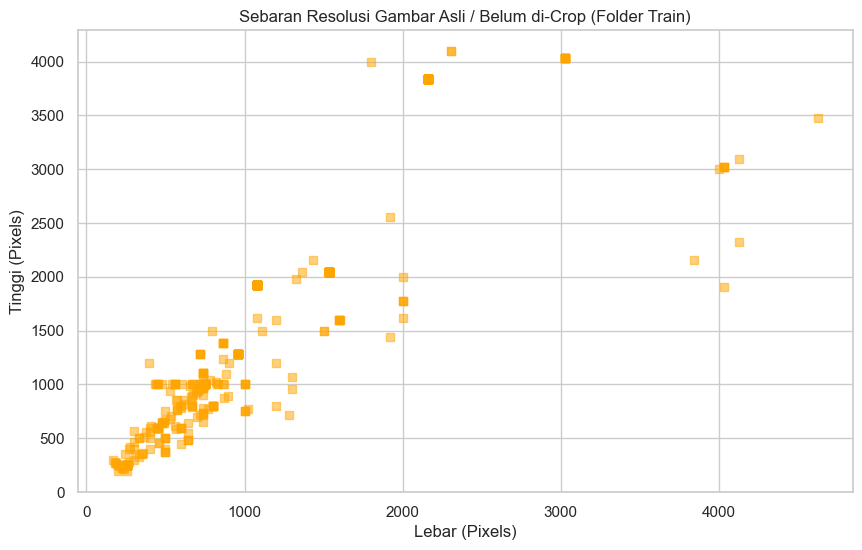

Total Sampel Dianalisis: 500 gambar
Rata-rata Lebar: 1186.14 pixels
Rata-rata Tinggi: 1734.07 pixels
Resolusi Terkecil: 168 x 194
Resolusi Terbesar: 4624 x 4096


In [14]:
train_widths = []
train_heights = []

# Mengambil sampel gambar dari folder train (maksimal 500 gambar agar cepat)
train_image_files = glob.glob(os.path.join(TRAIN_DIR, '*.*'))[:500]

for img_path in train_image_files:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            train_widths.append(w)
            train_heights.append(h)
    except:
        pass

# Visualisasi
plt.figure(figsize=(10, 6))
plt.scatter(train_widths, train_heights, alpha=0.5, color='orange', marker='s')
plt.title('Sebaran Resolusi Gambar Asli / Belum di-Crop (Folder Train)')
plt.xlabel('Lebar (Pixels)')
plt.ylabel('Tinggi (Pixels)')
plt.grid(True)
plt.show()

# Menampilkan statistik singkat
if len(train_widths) > 0:
    print(f"Total Sampel Dianalisis: {len(train_widths)} gambar")
    print(f"Rata-rata Lebar: {np.mean(train_widths):.2f} pixels")
    print(f"Rata-rata Tinggi: {np.mean(train_heights):.2f} pixels")
    print(f"Resolusi Terkecil: {min(train_widths)} x {min(train_heights)}")
    print(f"Resolusi Terbesar: {max(train_widths)} x {max(train_heights)}")
else:
    print("Tidak ada gambar yang berhasil dianalisis di folder train.")

## 7. Perbandingan Dimensi (Train vs Output)
Mari kita gabungkan plot sebaran dimensi dari folder `train` dan `output` dalam satu visualisasi untuk melihat perbedaan skalanya secara langsung.

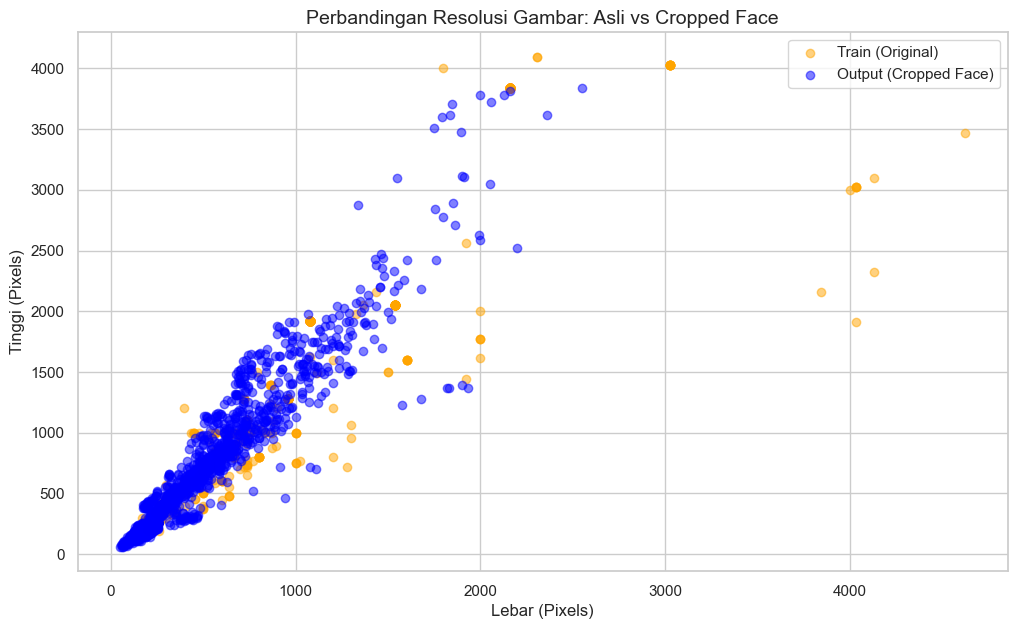

In [17]:
plt.figure(figsize=(12, 7))

# Plot gambar asli (Train)
plt.scatter(train_widths, train_heights, alpha=0.5, color='orange', label='Train (Original)')

# Plot gambar cropped (Output)
plt.scatter(widths, heights, alpha=0.5, color='blue', label='Output (Cropped Face)')

plt.title('Perbandingan Resolusi Gambar: Asli vs Cropped Face', fontsize=14)
plt.xlabel('Lebar (Pixels)', fontsize=12)
plt.ylabel('Tinggi (Pixels)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## 8. Analisis Kecerahan (Brightness) dan Kontras (Contrast)
Pada bagian ini, kita akan mengekstrak dua metrik utama dari gambar (diubah ke Grayscale):
1. **Kecerahan (Brightness):** Rata-rata nilai piksel.
2. **Kontras (Contrast):** Standar deviasi dari nilai piksel (sebaran intensitas gelap-terang).

Kita akan membandingkan gambar *Train* (utuh) dengan gambar *Output* (wajah saja).

Rata-rata Kecerahan (Train): 129.19
Rata-rata Kecerahan (Output): 117.85
Rata-rata Kontras (Train): 60.99
Rata-rata Kontras (Output): 57.06


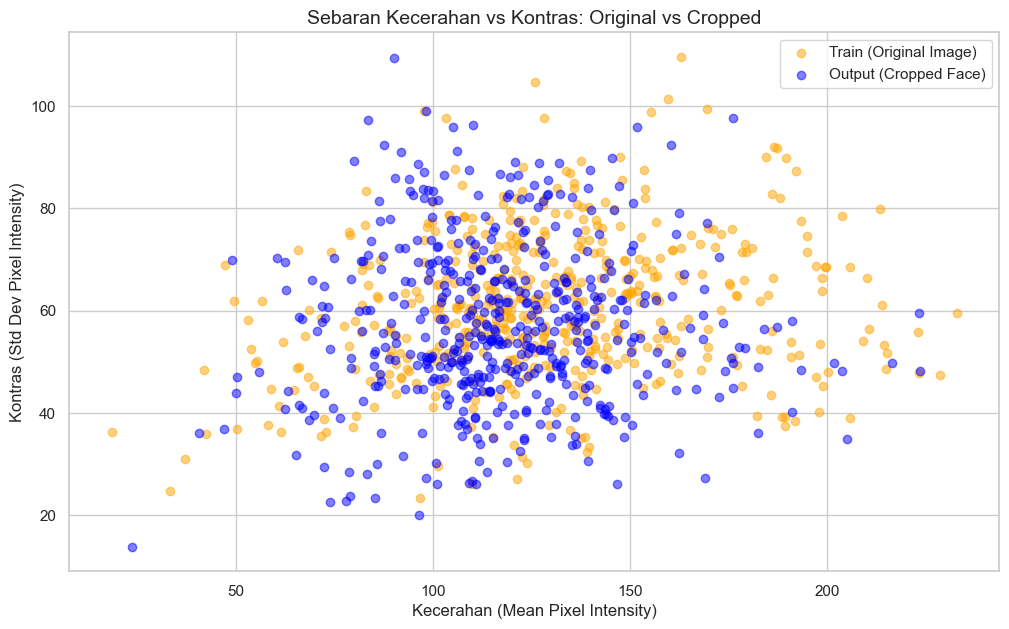

In [21]:
def get_brightness_contrast(image_paths, max_samples=500):
    brightness = []
    contrast = []
    
    for img_path in image_paths[:max_samples]:
        img = cv2.imread(img_path)
        if img is not None:
            # Ubah ke grayscale untuk kemudahan perhitungan intensitas cahaya
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness.append(np.mean(gray))
            contrast.append(np.std(gray))
            
    return brightness, contrast

# Mengumpulkan sampel path untuk folder output (gabungan semua kelas)
output_image_files = []
for cls in classes:
    output_image_files.extend(glob.glob(os.path.join(OUTPUT_DIR, cls, '*.*'))[:100]) # Ambil 100 per kelas agar adil

# Menghitung metrik
train_b, train_c = get_brightness_contrast(train_image_files)
out_b, out_c = get_brightness_contrast(output_image_files)

print(f"Rata-rata Kecerahan (Train): {np.mean(train_b):.2f}")
print(f"Rata-rata Kecerahan (Output): {np.mean(out_b):.2f}")
print(f"Rata-rata Kontras (Train): {np.mean(train_c):.2f}")
print(f"Rata-rata Kontras (Output): {np.mean(out_c):.2f}")

# Visualisasi Scatter Plot Kecerahan vs Kontras
plt.figure(figsize=(12, 7))
plt.scatter(train_b, train_c, alpha=0.5, color='orange', label='Train (Original Image)')
plt.scatter(out_b, out_c, alpha=0.5, color='blue', label='Output (Cropped Face)')

plt.title('Sebaran Kecerahan vs Kontras: Original vs Cropped', fontsize=14)
plt.xlabel('Kecerahan (Mean Pixel Intensity)')
plt.ylabel('Kontras (Std Dev Pixel Intensity)')
plt.legend()
plt.grid(True)
plt.show()

## 9. Analisis Distribusi Warna (RGB Histograms)
Wajah manusia (*realperson*) memiliki distribusi warna kemerahan (hemoglobin) yang khas dibandingkan dengan topeng silikon, manekin, atau layar monitor (*fake_screen*). Mari kita lihat rata-rata histogram warna (Red, Green, Blue) dari gambar asli vs yang sudah di-crop.

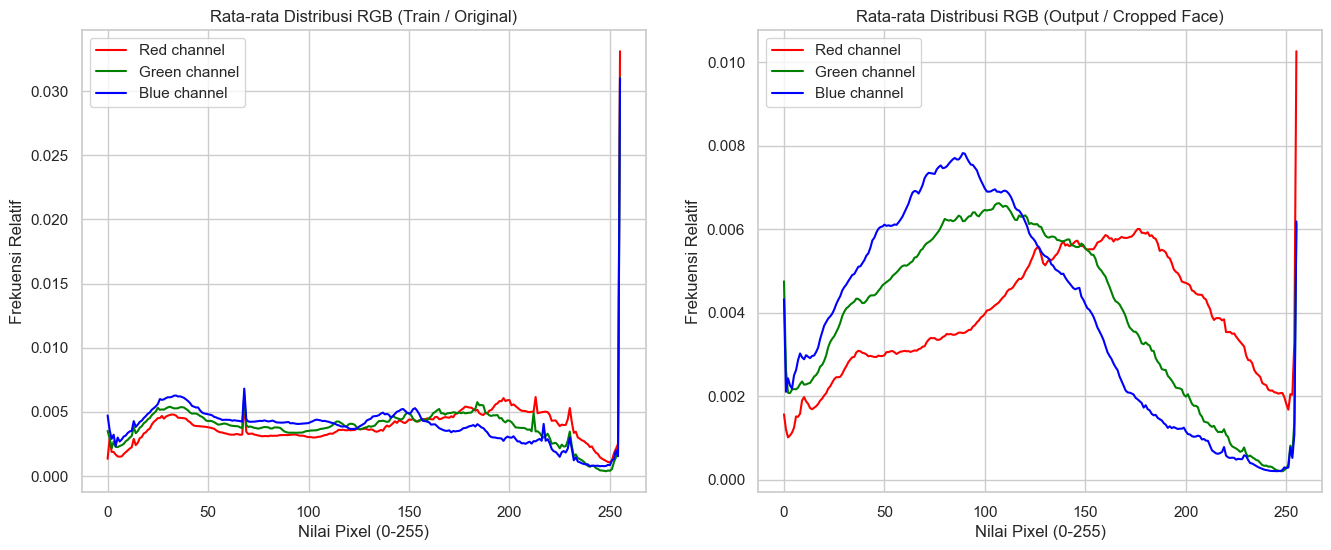

In [19]:
def get_average_rgb_histogram(image_paths, max_samples=300):
    avg_hist = np.zeros((256, 3)) # 256 bins, 3 channels
    valid_count = 0
    
    for img_path in image_paths[:max_samples]:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            for i in range(3): # 0:R, 1:G, 2:B
                hist = cv2.calcHist([img], [i], None, [256], [0, 256])
                avg_hist[:, i] += hist.flatten()
            valid_count += 1
            
    if valid_count > 0:
        avg_hist /= valid_count # Rata-rata
        # Normalisasi ke skala 0-1 untuk perbandingan
        for i in range(3):
            if np.sum(avg_hist[:, i]) > 0:
                avg_hist[:, i] /= np.sum(avg_hist[:, i])
                
    return avg_hist

# Menghitung histogram
hist_train = get_average_rgb_histogram(train_image_files)
hist_out = get_average_rgb_histogram(output_image_files)

# Visualisasi Histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ('red', 'green', 'blue')

# Plot Train
for i, col in enumerate(colors):
    axes[0].plot(hist_train[:, i], color=col, label=f'{col.capitalize()} channel')
axes[0].set_title('Rata-rata Distribusi RGB (Train / Original)')
axes[0].set_xlabel('Nilai Pixel (0-255)')
axes[0].set_ylabel('Frekuensi Relatif')
axes[0].legend()

# Plot Output
for i, col in enumerate(colors):
    axes[1].plot(hist_out[:, i], color=col, label=f'{col.capitalize()} channel')
axes[1].set_title('Rata-rata Distribusi RGB (Output / Cropped Face)')
axes[1].set_xlabel('Nilai Pixel (0-255)')
axes[1].set_ylabel('Frekuensi Relatif')
axes[1].legend()

plt.show()

## 10. Insight Kritis untuk Preprocessing Wajah Asli vs Palsu
Sebagai tambahan, kita perlu melihat apakah ada perbedaan kontras yang mencolok antara kelas `realperson` dan kelas-kelas *fake* (`fake_screen`, `fake_printed`, dll) di dalam folder `output`. Ini adalah inti dari deteksi spoofing.

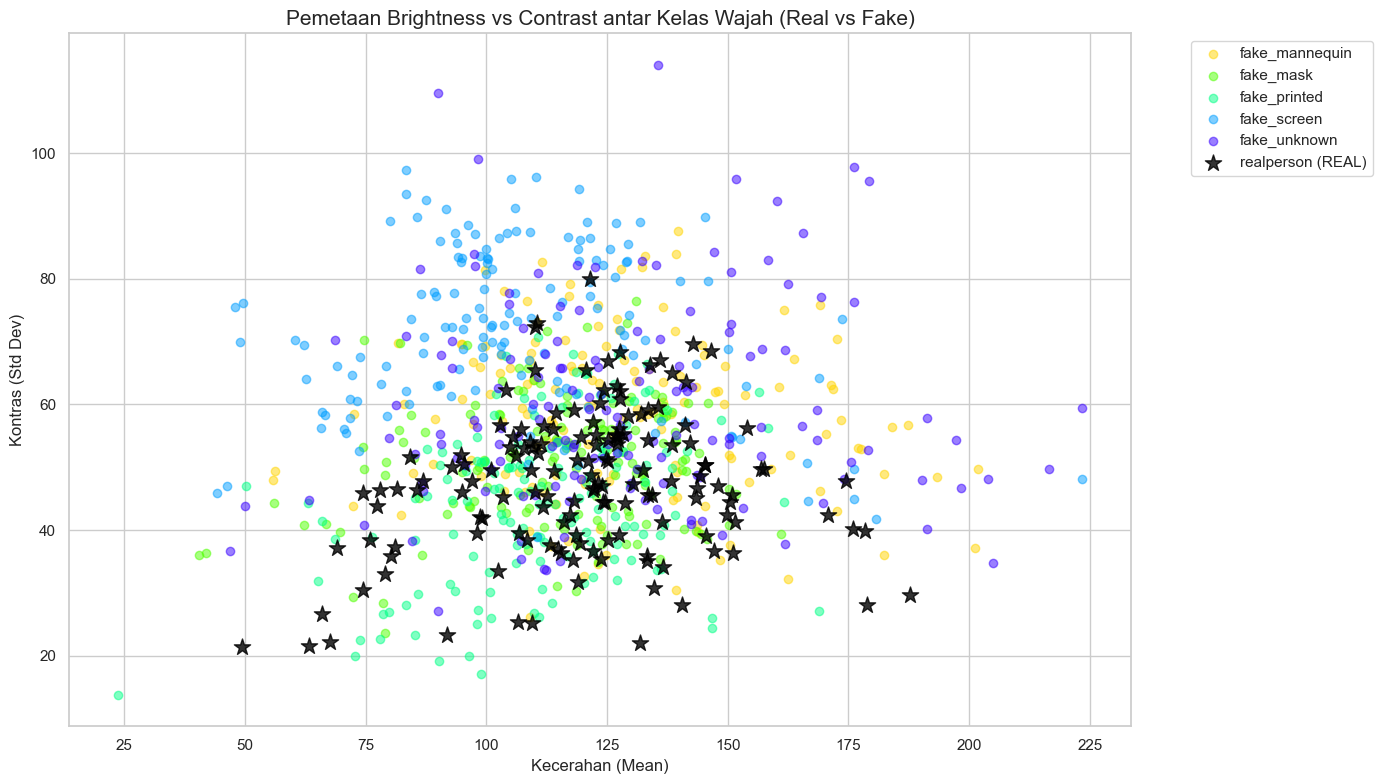

In [20]:
plt.figure(figsize=(14, 8))

# Warna berbeda untuk setiap kelas
palette = sns.color_palette("hsv", len(classes))

for idx, cls in enumerate(classes):
    cls_paths = glob.glob(os.path.join(OUTPUT_DIR, cls, '*.*'))[:150]
    b, c = get_brightness_contrast(cls_paths)
    
    # Jika kelas adalah realperson, buat lebih tebal/berbeda agar mudah dianalisis
    if cls == 'realperson':
        plt.scatter(b, c, alpha=0.8, color='black', marker='*', s=150, label=f'{cls} (REAL)')
    else:
        plt.scatter(b, c, alpha=0.5, color=palette[idx], label=f'{cls}')

plt.title('Pemetaan Brightness vs Contrast antar Kelas Wajah (Real vs Fake)', fontsize=15)
plt.xlabel('Kecerahan (Mean)')
plt.ylabel('Kontras (Std Dev)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()